# Manual Gradient Descent for Initial Condition Optimization

This notebook optimizes initial conditions (x_0) using manual gradient descent with visualization of RMSE and predictions at each step.

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
import os
import sys
from pathlib import Path
from datetime import datetime
from typing import Tuple, Dict
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output, display
import pandas as pd

# Add paths
sys.path.append(str(Path.cwd().parent / "glonet_daily_forecast_local"))
sys.path.append(str(Path.cwd().parent / "src/glonet"))
sys.path.append(str(Path.cwd() / "src"))

from utility import get_normalizer1, get_normalizer2, get_normalizer3
from utility import get_denormalizer1, get_denormalizer2, get_denormalizer3
from modelp2 import Glonet
from optimIC_GD_glonetLit import GlonetGradientCheckpointing

# Set matplotlib style
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All imports successful")

Error importing huggingface_hub.hf_api: No module named 'filelock'


/Odyssey/private/j25lee/miniforge3/envs/glon/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✓ All imports successful


## 2. Configuration

In [2]:
# Configuration parameters
CONFIG = {
    'data_path': "/Odyssey/public/glonet/glorys12_1993-01-01_to_1993-06-30_init_states/combined_input.nc", 
    'model_location': "/Odyssey/public/glonet/TrainedWeights",
    'learning_rate': 1,
    'num_iterations': 100,
    'sample_idx': 0,
    'sequence_length': 2,
    'forecast_horizon': 1,
    'device': "cuda:0" if torch.cuda.is_available() else "cpu",
    'output_dir': f"outputs/notebook_optim_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    'plot_frequency': 10,  # Plot every N iterations
}

# Create output directory
os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  data_path: /Odyssey/public/glonet/glorys12_1993-01-01_to_1993-06-30_init_states/combined_input.nc
  model_location: /Odyssey/public/glonet/TrainedWeights
  learning_rate: 1
  num_iterations: 100
  sample_idx: 0
  sequence_length: 2
  forecast_horizon: 1
  device: cuda:0
  output_dir: outputs/notebook_optim_20260121_093302
  plot_frequency: 10


## 3. Load Models and Normalizers

In [3]:
print("Loading normalizers and denormalizers...")
normalizer1 = get_normalizer1(CONFIG['model_location'])
normalizer2 = get_normalizer2(CONFIG['model_location'])
normalizer3 = get_normalizer3(CONFIG['model_location'])

denormalizer1 = get_denormalizer1(CONFIG['model_location'])
denormalizer2 = get_denormalizer2(CONFIG['model_location'])
denormalizer3 = get_denormalizer3(CONFIG['model_location'])

print("✓ Normalizers loaded")

Loading normalizers and denormalizers...
✓ Normalizers loaded


In [4]:
def load_checkpoint_model(checkpoint_path: str, shape_in: Tuple, device: str):
    """Load a checkpoint-based model with gradient checkpointing."""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = GlonetGradientCheckpointing(shape_in=shape_in)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.train()  # Enable gradient checkpointing
    for param in model.parameters():
        param.requires_grad = False
    return model

print("Loading pretrained models...")
model1 = load_checkpoint_model(
    f"{CONFIG['model_location']}/glonet_part1.pth",
    shape_in=(2, 5, 672, 1440),
    device=CONFIG['device']
)
model2 = load_checkpoint_model(
    f"{CONFIG['model_location']}/glonet_part2.pth",
    shape_in=(2, 40, 672, 1440),
    device=CONFIG['device']
)
model3 = load_checkpoint_model(
    f"{CONFIG['model_location']}/glonet_part3.pth",
    shape_in=(2, 40, 672, 1440),
    device=CONFIG['device']
)

loss_fn = nn.MSELoss()

print("✓ Models loaded successfully")

Loading pretrained models...
720
720
720
✓ Models loaded successfully


## 4. Load and Prepare Data

In [5]:
print(f"Loading dataset from {CONFIG['data_path']}...")
dataset = xr.open_dataset(CONFIG['data_path'])

# Extract input sequence and target
input_sequence = dataset.isel(
    time=slice(CONFIG['sample_idx'], CONFIG['sample_idx'] + CONFIG['sequence_length'])
)
target_time_idx = CONFIG['sample_idx'] + CONFIG['sequence_length'] + CONFIG['forecast_horizon'] - 1
target = dataset.isel(time=target_time_idx)

# Store coordinates
coords = {
    'time': input_sequence['time'].values,
    'target_time': target['time'].values,
    'lat': input_sequence['lat'].values,
    'lon': input_sequence['lon'].values
}

print(f"Input sequence shape: {input_sequence['data'].shape}")
print(f"Target shape: {target['data'].shape}")
print(f"Target time: {coords['target_time']}")

Loading dataset from /Odyssey/public/glonet/glorys12_1993-01-01_to_1993-06-30_init_states/combined_input.nc...
Input sequence shape: (2, 85, 672, 1440)
Target shape: (85, 672, 1440)
Target time: 1993-01-03T00:00:00.000000000


In [6]:
# Create ocean masks
sample_data = dataset.isel(time=CONFIG['sample_idx'])
data_values = sample_data['data'].values
land_mask = np.isnan(data_values).astype(np.float32)

ocean_mask_1 = torch.from_numpy((1.0 - land_mask[0:5, :, :]).copy()).float().to(CONFIG['device'])
ocean_mask_2 = torch.from_numpy((1.0 - land_mask[5:45, :, :]).copy()).float().to(CONFIG['device'])
ocean_mask_3 = torch.from_numpy((1.0 - land_mask[45:85, :, :]).copy()).float().to(CONFIG['device'])
ocean_mask_all = torch.cat([ocean_mask_1, ocean_mask_2, ocean_mask_3], dim=0)

print(f"Ocean mask 1: {ocean_mask_1.shape}")
print(f"Ocean mask 2: {ocean_mask_2.shape}")
print(f"Ocean mask 3: {ocean_mask_3.shape}")

Ocean mask 1: torch.Size([5, 672, 1440])
Ocean mask 2: torch.Size([40, 672, 1440])
Ocean mask 3: torch.Size([40, 672, 1440])


In [7]:
# Prepare initial conditions and target
input_data = input_sequence['data'].values
target_data = target['data'].values

input_data = np.nan_to_num(input_data, nan=0.0)
target_data = np.nan_to_num(target_data, nan=0.0)

x0 = torch.from_numpy(input_data.copy()).float().unsqueeze(0).to(CONFIG['device'])
x0_ref = x0.clone()
target_tensor = torch.from_numpy(target_data.copy()).float().unsqueeze(0).to(CONFIG['device'])

x0.requires_grad = True
x0_ref.requires_grad = False

print(f"Initial condition shape: {x0.shape}")
print(f"Target shape: {target_tensor.shape}")
print("✓ Data preparation complete")

Initial condition shape: torch.Size([1, 2, 85, 672, 1440])
Target shape: torch.Size([1, 85, 672, 1440])
✓ Data preparation complete


## 5. Define Functions

In [17]:
def forward(x):
    """Forward pass through the models."""
    
    with torch.enable_grad():
        x1 = x[:, :, 0:5, :, :] 
        x1_in_std = normalizer1(x1) * ocean_mask_1.unsqueeze(0).unsqueeze(0)
        x2 = x[:, :, 5:45, :, :]
        x2_in_std = normalizer2(x2)  * ocean_mask_2.unsqueeze(0).unsqueeze(0)
        x3 = x[:, :, 45:85, :, :] 
        x3_in_std = normalizer3(x3) * ocean_mask_3.unsqueeze(0).unsqueeze(0)
    
        y_hat1 = model1(x1_in_std)[:, 0, :, :, :]
        y_hat2 = model2(x2_in_std)[:, 0, :, :, :]
        y_hat3 = model3(x3_in_std)[:, 0, :, :, :]
    
        y_hat1 = denormalizer1(y_hat1)
        y_hat2 = denormalizer2(y_hat2)
        y_hat3 = denormalizer3(y_hat3)
    
    y_hat = torch.cat([y_hat1, y_hat2, y_hat3], dim=1)
    x0_in_std = torch.cat([x1_in_std, x2_in_std, x3_in_std], dim=2)
    
    return x0_in_std, y_hat

def compute_loss(y_hat):
    """Compute MSE loss."""
    loss_ssh = loss_fn(y_hat[:, 0:1, :, :], target_tensor[:, 0:1, :, :])
    loss_t = loss_fn(torch.cat([y_hat[:, 1:2, :, :], y_hat[:, 5:15, :, :]], dim=1), 
                     torch.cat([target_tensor[:, 2:3, :, :], target_tensor[:, 5:15, :, :]], dim=1))
    loss_s = loss_fn(torch.cat([y_hat[:, 2:3, :, :], y_hat[:, 15:25, :, :]], dim=1), 
                     torch.cat([target_tensor[:, 2:3, :, :], target_tensor[:, 15:25, :, :]], dim=1))
    loss_u = loss_fn(torch.cat([y_hat[:, 3:4, :, :], y_hat[:, 25:35, :, :]], dim=1), 
                     torch.cat([target_tensor[:, 3:4, :, :], target_tensor[:, 25:35, :, :]], dim=1))
    loss_v = loss_fn(torch.cat([y_hat[:, 4:5, :, :], y_hat[:, 35:45, :, :]], dim=1), 
                     torch.cat([target_tensor[:, 4:5, :, :], target_tensor[:, 35:45, :, :]], dim=1))
    
    # loss1 = loss_fn(y_hat[:, 0:5, :, :], target_tensor[:, 0:5, :, :])
    # loss2 = loss_fn(y_hat[:, 5:45, :, :], target_tensor[:, 5:45, :, :])
    # loss3 = loss_fn(y_hat[:, 45:85, :, :], target_tensor[:, 45:85, :, :])
    loss_total = loss_ssh + loss_t + loss_s + loss_u + loss_v
    return loss_total, loss_ssh, loss_t, loss_s, loss_u, loss_v

print("✓ Forward and loss functions defined")

✓ Forward and loss functions defined


In [18]:
def compute_rmse_metrics(y_hat, x0_current, x0_reference):
    """Compute RMSE metrics for predictions and initial conditions."""
    with torch.no_grad():
        # Prediction errors
        squared_errors = (target_tensor - y_hat) ** 2
        squared_errors_masked = squared_errors * ocean_mask_all.unsqueeze(0)
        n_ocean_points = ocean_mask_all.unsqueeze(0).sum(dim=(2, 3))
        mse_per_channel = squared_errors_masked.sum(dim=(2, 3)) / (n_ocean_points + 1e-10)
        rmse_per_channel = torch.sqrt(mse_per_channel).cpu().numpy().squeeze(0)
        
        # IC errors
        ic_squared_errors = (x0_reference - x0_current) ** 2
        ic_squared_errors_masked = ic_squared_errors * ocean_mask_all.unsqueeze(0).unsqueeze(0)
        ic_mse_per_channel = ic_squared_errors_masked.sum(dim=(3, 4)) / (n_ocean_points + 1e-10)
        ic_rmse_per_channel = torch.sqrt(ic_mse_per_channel).cpu().numpy().squeeze(0)
        
        # Compute per-variable metrics
        metrics = {
            'pred': {
                'SSH': float(rmse_per_channel[0]),
                'thetao': [float(rmse_per_channel[1:2].mean()), 
                               float(rmse_per_channel[5:15].mean()), 
                               float(rmse_per_channel[45:55].mean())],
                'so': [float(rmse_per_channel[2:3].mean()), 
                           float(rmse_per_channel[15:25].mean()), 
                           float(rmse_per_channel[55:65].mean())],
                'uo': [float(rmse_per_channel[3:4].mean()), 
                           float(rmse_per_channel[25:35].mean()), 
                           float(rmse_per_channel[65:75].mean())],
                'vo': [float(rmse_per_channel[4:5].mean()), 
                           float(rmse_per_channel[35:45].mean()), 
                           float(rmse_per_channel[75:85].mean())],
            },
            'ic': {
                'SSH': float(ic_rmse_per_channel[1, 0]),
                'thetao': [float(ic_rmse_per_channel[1, 1:2].mean()), 
                              float(ic_rmse_per_channel[1, 5:15].mean()), 
                              float(ic_rmse_per_channel[1, 45:55].mean())],
                'so': [float(ic_rmse_per_channel[1, 2:3].mean()), 
                           float(ic_rmse_per_channel[1, 15:25].mean()), 
                           float(ic_rmse_per_channel[1, 55:65].mean())],
                'uo': [float(ic_rmse_per_channel[1, 3:4].mean()), 
                           float(ic_rmse_per_channel[1, 25:35].mean()), 
                           float(ic_rmse_per_channel[1, 65:75].mean())],
                'vo': [float(ic_rmse_per_channel[1, 4:5].mean()), 
                           float(ic_rmse_per_channel[1, 35:45].mean()), 
                           float(ic_rmse_per_channel[1, 75:85].mean())],
            }
        }
        
        return metrics

print("✓ RMSE computation function defined")

✓ RMSE computation function defined


## 6. Visualization Functions

In [19]:
def plot_rmse_evolution(history, iteration):
    """Plot RMSE evolution over iterations with separate subplots for each depth level."""
    # Create figure with 3 columns (Prediction RMSE, IC RMSE, Loss) and multiple rows
    fig, axes = plt.subplots(14, 3, figsize=(24, 36))
    fig.suptitle(f'RMSE and Loss Evolution - Iteration {iteration}', fontsize=16, fontweight='bold')
    
    variables = ['SSH', 'thetao', 'so', 'uo', 'vo']
    var_titles = ['SSH (Sea Surface Height)', 'Temperature (thetao)', 'Salinity (so)', 
                  'Eastward Velocity (uo)', 'Northward Velocity (vo)']
    loss_keys = ['loss_ssh', 'loss_t', 'loss_s', 'loss_u', 'loss_v']
    depths = ['surface', 'shallow', 'deep']
    
    row_idx = 0
    
    for var, title, loss_key in zip(variables, var_titles, loss_keys):
        pred_rmse = [h['pred'][var] for h in history]
        ic_rmse = [h['ic'][var] for h in history]
        var_loss = [h[loss_key] for h in history]
        
        if isinstance(pred_rmse[0], list):
            # Variable with depth levels
            for depth_idx, depth in enumerate(depths):
                pred_rmse_depth = [p[depth_idx] for p in pred_rmse]
                ic_rmse_depth = [ic[depth_idx] for ic in ic_rmse]
                
                # Prediction RMSE subplot
                axes[row_idx, 0].plot(pred_rmse_depth, 'b-', linewidth=2)
                axes[row_idx, 0].set_xlabel('Iteration', fontsize=10)
                axes[row_idx, 0].set_ylabel('RMSE', fontsize=10)
                axes[row_idx, 0].set_title(f'{title} - {depth} (Pred)', fontsize=11, fontweight='bold')
                axes[row_idx, 0].grid(True, alpha=0.3)
                
                # IC RMSE subplot
                axes[row_idx, 1].plot(ic_rmse_depth, 'r-', linewidth=2)
                axes[row_idx, 1].set_xlabel('Iteration', fontsize=10)
                axes[row_idx, 1].set_ylabel('RMSE', fontsize=10)
                axes[row_idx, 1].set_title(f'{title} - {depth} (IC)', fontsize=11, fontweight='bold')
                axes[row_idx, 1].grid(True, alpha=0.3)
                
                # Loss subplot (only for first depth level of each variable)
                if depth_idx == 0:
                    axes[row_idx, 2].plot(var_loss, 'g-', linewidth=2)
                    axes[row_idx, 2].set_xlabel('Iteration', fontsize=10)
                    axes[row_idx, 2].set_ylabel('Loss', fontsize=10)
                    axes[row_idx, 2].set_title(f'{title} Loss', fontsize=11, fontweight='bold')
                    axes[row_idx, 2].grid(True, alpha=0.3)
                else:
                    # Hide loss subplot for non-first depth levels
                    axes[row_idx, 2].axis('off')
                
                row_idx += 1
        else:
            # SSH (no depth levels)
            # Prediction RMSE subplot
            axes[row_idx, 0].plot(pred_rmse, 'b-', linewidth=2)
            axes[row_idx, 0].set_xlabel('Iteration', fontsize=10)
            axes[row_idx, 0].set_ylabel('RMSE', fontsize=10)
            axes[row_idx, 0].set_title(f'{title} (Pred)', fontsize=11, fontweight='bold')
            axes[row_idx, 0].grid(True, alpha=0.3)
            
            # IC RMSE subplot
            axes[row_idx, 1].plot(ic_rmse, 'r-', linewidth=2)
            axes[row_idx, 1].set_xlabel('Iteration', fontsize=10)
            axes[row_idx, 1].set_ylabel('RMSE', fontsize=10)
            axes[row_idx, 1].set_title(f'{title} (IC)', fontsize=11, fontweight='bold')
            axes[row_idx, 1].grid(True, alpha=0.3)
            
            # Loss subplot
            axes[row_idx, 2].plot(var_loss, 'g-', linewidth=2)
            axes[row_idx, 2].set_xlabel('Iteration', fontsize=10)
            axes[row_idx, 2].set_ylabel('Loss', fontsize=10)
            axes[row_idx, 2].set_title(f'{title} Loss', fontsize=11, fontweight='bold')
            axes[row_idx, 2].grid(True, alpha=0.3)
            
            row_idx += 1
    
    # Total Loss plot (spanning all columns in the last row)
    fig.delaxes(axes[row_idx, 1])
    fig.delaxes(axes[row_idx, 2])
    axes[row_idx, 0].set_position([0.125, 0.025, 0.775, 0.055])
    losses = [h['loss'] for h in history]
    axes[row_idx, 0].plot(losses, 'purple', linewidth=2.5)
    axes[row_idx, 0].set_xlabel('Iteration', fontsize=11)
    axes[row_idx, 0].set_ylabel('Total Loss', fontsize=11)
    axes[row_idx, 0].set_title('Total Loss (Sum of All Variables)', fontsize=12, fontweight='bold')
    axes[row_idx, 0].grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

print("✓ RMSE evolution plot function defined")

✓ RMSE evolution plot function defined


In [20]:
def plot_predictions(y_hat, target_tensor, coords, iteration, channel_idx=0):
    """Plot current predictions vs target with proper lat-lon coordinates."""
    with torch.no_grad():
        pred = y_hat[0, channel_idx].cpu().numpy()
        tgt = target_tensor[0, channel_idx].cpu().numpy()
        error = pred - tgt
    
    # Replace zeros with NaN for ocean-only visualization
    pred = np.where(pred == 0, np.nan, pred)
    tgt = np.where(tgt == 0, np.nan, tgt)
    error = np.where(np.isnan(pred) | np.isnan(tgt), np.nan, error)
    
    # Get lat/lon coordinates
    lons = coords['lon']
    lats = coords['lat']
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'Channel {channel_idx} - Iteration {iteration}', fontsize=14, fontweight='bold')
    
    # Prediction
    im0 = axes[0].pcolormesh(lons, lats, pred, cmap='viridis', shading='auto')
    axes[0].set_title('Prediction', fontsize=12)
    axes[0].set_xlabel('Longitude (°E)', fontsize=11)
    axes[0].set_ylabel('Latitude (°N)', fontsize=11)
    axes[0].set_aspect('equal')
    plt.colorbar(im0, ax=axes[0], label='Value', fraction=0.025, pad=0.04)
    
    # Target
    im1 = axes[1].pcolormesh(lons, lats, tgt, cmap='viridis', shading='auto')
    axes[1].set_title('Target', fontsize=12)
    axes[1].set_xlabel('Longitude (°E)', fontsize=11)
    axes[1].set_ylabel('Latitude (°N)', fontsize=11)
    axes[1].set_aspect('equal')
    plt.colorbar(im1, ax=axes[1], label='Value', fraction=0.025, pad=0.04)
    
    # Error
    max_abs_error = np.nanmax(np.abs(error))
    im2 = axes[2].pcolormesh(lons, lats, error, cmap='RdBu_r', shading='auto',
                             vmin=-max_abs_error, vmax=max_abs_error)
    axes[2].set_title(f'Error (Pred - Target)', fontsize=12)
    axes[2].set_xlabel('Longitude (°E)', fontsize=11)
    axes[2].set_ylabel('Latitude (°N)', fontsize=11)
    axes[2].set_aspect('equal')
    plt.colorbar(im2, ax=axes[2], label='Error', fraction=0.025, pad=0.04)
    
    plt.tight_layout()
    return fig

print("✓ Prediction visualization function defined")

✓ Prediction visualization function defined


## 7. Initial State Analysis

In [21]:
# Compute initial predictions
print("Computing initial predictions...")
with torch.no_grad():
    x0_in_std_init, y_hat_init = forward(x0)

    initial_metrics = compute_rmse_metrics(y_hat_init, x0, x0_ref)
    total_loss_init, loss_ssh_init, loss_t_init, loss_s_init, loss_u_init, loss_v_init = compute_loss(y_hat_init)
    
print("\n" + "="*60)
print("INITIAL STATE ANALYSIS")
print("="*60)
print(f"Total Loss: {total_loss_init.item():.6f}")
print(f"\nPrediction RMSE:")
for var, rmse in initial_metrics['pred'].items():
    if isinstance(rmse, list):
        rmse_str = [f"{r:.6e}" for r in rmse]
        print(f"  {var:10s}: {rmse_str}")
    else:
        print(f"  {var:10s}: {rmse:.6e}")
print(f"\nInitial Condition RMSE:")
for var, rmse in initial_metrics['ic'].items():
    if isinstance(rmse, list):
        rmse_str = [f"{r:.6e}" for r in rmse]
        print(f"  {var:10s}: {rmse_str}")
    else:
        print(f"  {var:10s}: {rmse:.6e}")
print("="*60)

Computing initial predictions...

INITIAL STATE ANALYSIS
Total Loss: 506.188446

Prediction RMSE:
  SSH       : 2.053619e-02
  thetao    : ['2.979476e-01', '1.911936e-01', '4.770263e-02']
  so        : ['1.005794e-01', '3.046184e-02', '7.009848e-03']
  uo        : ['3.137856e-02', '1.125496e-02', '5.652571e-03']
  vo        : ['3.004878e-02', '1.081635e-02', '5.719401e-03']

Initial Condition RMSE:
  SSH       : 0.000000e+00
  thetao    : ['0.000000e+00', '0.000000e+00', '0.000000e+00']
  so        : ['0.000000e+00', '0.000000e+00', '0.000000e+00']
  uo        : ['0.000000e+00', '0.000000e+00', '0.000000e+00']
  vo        : ['0.000000e+00', '0.000000e+00', '0.000000e+00']


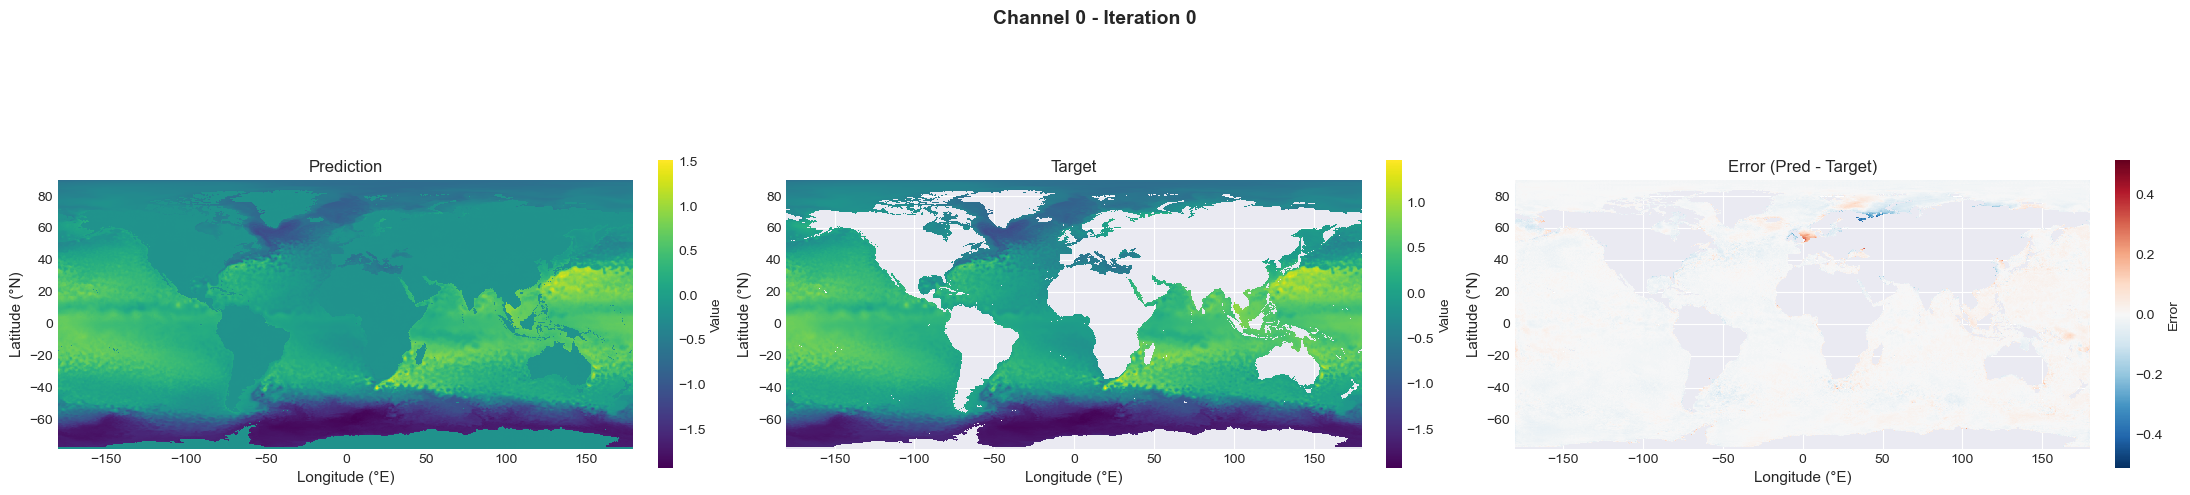

In [22]:
# Visualize initial predictions (SSH channel)
channel_to_plot = 0  # SSH channel
fig = plot_predictions(y_hat_init, target_tensor, coords, 0, channel_idx=channel_to_plot)
# plt.savefig(f"{CONFIG['output_dir']}/initial_prediction_ch{channel_to_plot}.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Optimization Loop

**Instructions:** Run this cell to start the optimization. 
It will automatically display visualizations every N iterations (configured in `plot_frequency`). 
You can stop it at any time using the stop button.

In [23]:
# Initialize tracking variables
history = []
best_loss = float('inf')
best_y_hat = None
best_x0 = None
best_iteration = 0

# Store initial metrics
history.append({
    'loss': total_loss_init.item(),
    'loss_ssh': loss_ssh_init.item(),
    'loss_t': loss_t_init.item(),
    'loss_s': loss_s_init.item(),
    'loss_u': loss_u_init.item(),
    'loss_v': loss_v_init.item(),   
    'pred': initial_metrics['pred'],
    'ic': initial_metrics['ic']
})

print("\n" + "="*60)
print("STARTING OPTIMIZATION")
print("="*60)
print(f"You can stop at any time and inspect the results")
print(f"Plots will be displayed every {CONFIG['plot_frequency']} iterations")
print("="*60)


STARTING OPTIMIZATION
You can stop at any time and inspect the results
Plots will be displayed every 10 iterations



Iteration 100/100
Total Loss: 505.344208
Best Loss: 505.344208 (iteration 100)

Prediction RMSE:
  SSH       : 2.576730e-02
  thetao    : ['3.726469e-01', '1.954594e-01', '4.770263e-02']
  so        : ['1.071636e-01', '3.083540e-02', '7.009848e-03']
  uo        : ['3.643058e-02', '1.163344e-02', '5.652571e-03']
  vo        : ['3.557762e-02', '1.115940e-02', '5.719401e-03']

Initial Condition RMSE:
  SSH       : 3.061084e-03
  thetao    : ['6.609583e-05', '2.915043e-05', '0.000000e+00']
  so        : ['1.951780e-04', '1.478375e-04', '0.000000e+00']
  uo        : ['4.486141e-03', '7.084588e-04', '0.000000e+00']
  vo        : ['4.888572e-03', '7.490200e-04', '0.000000e+00']


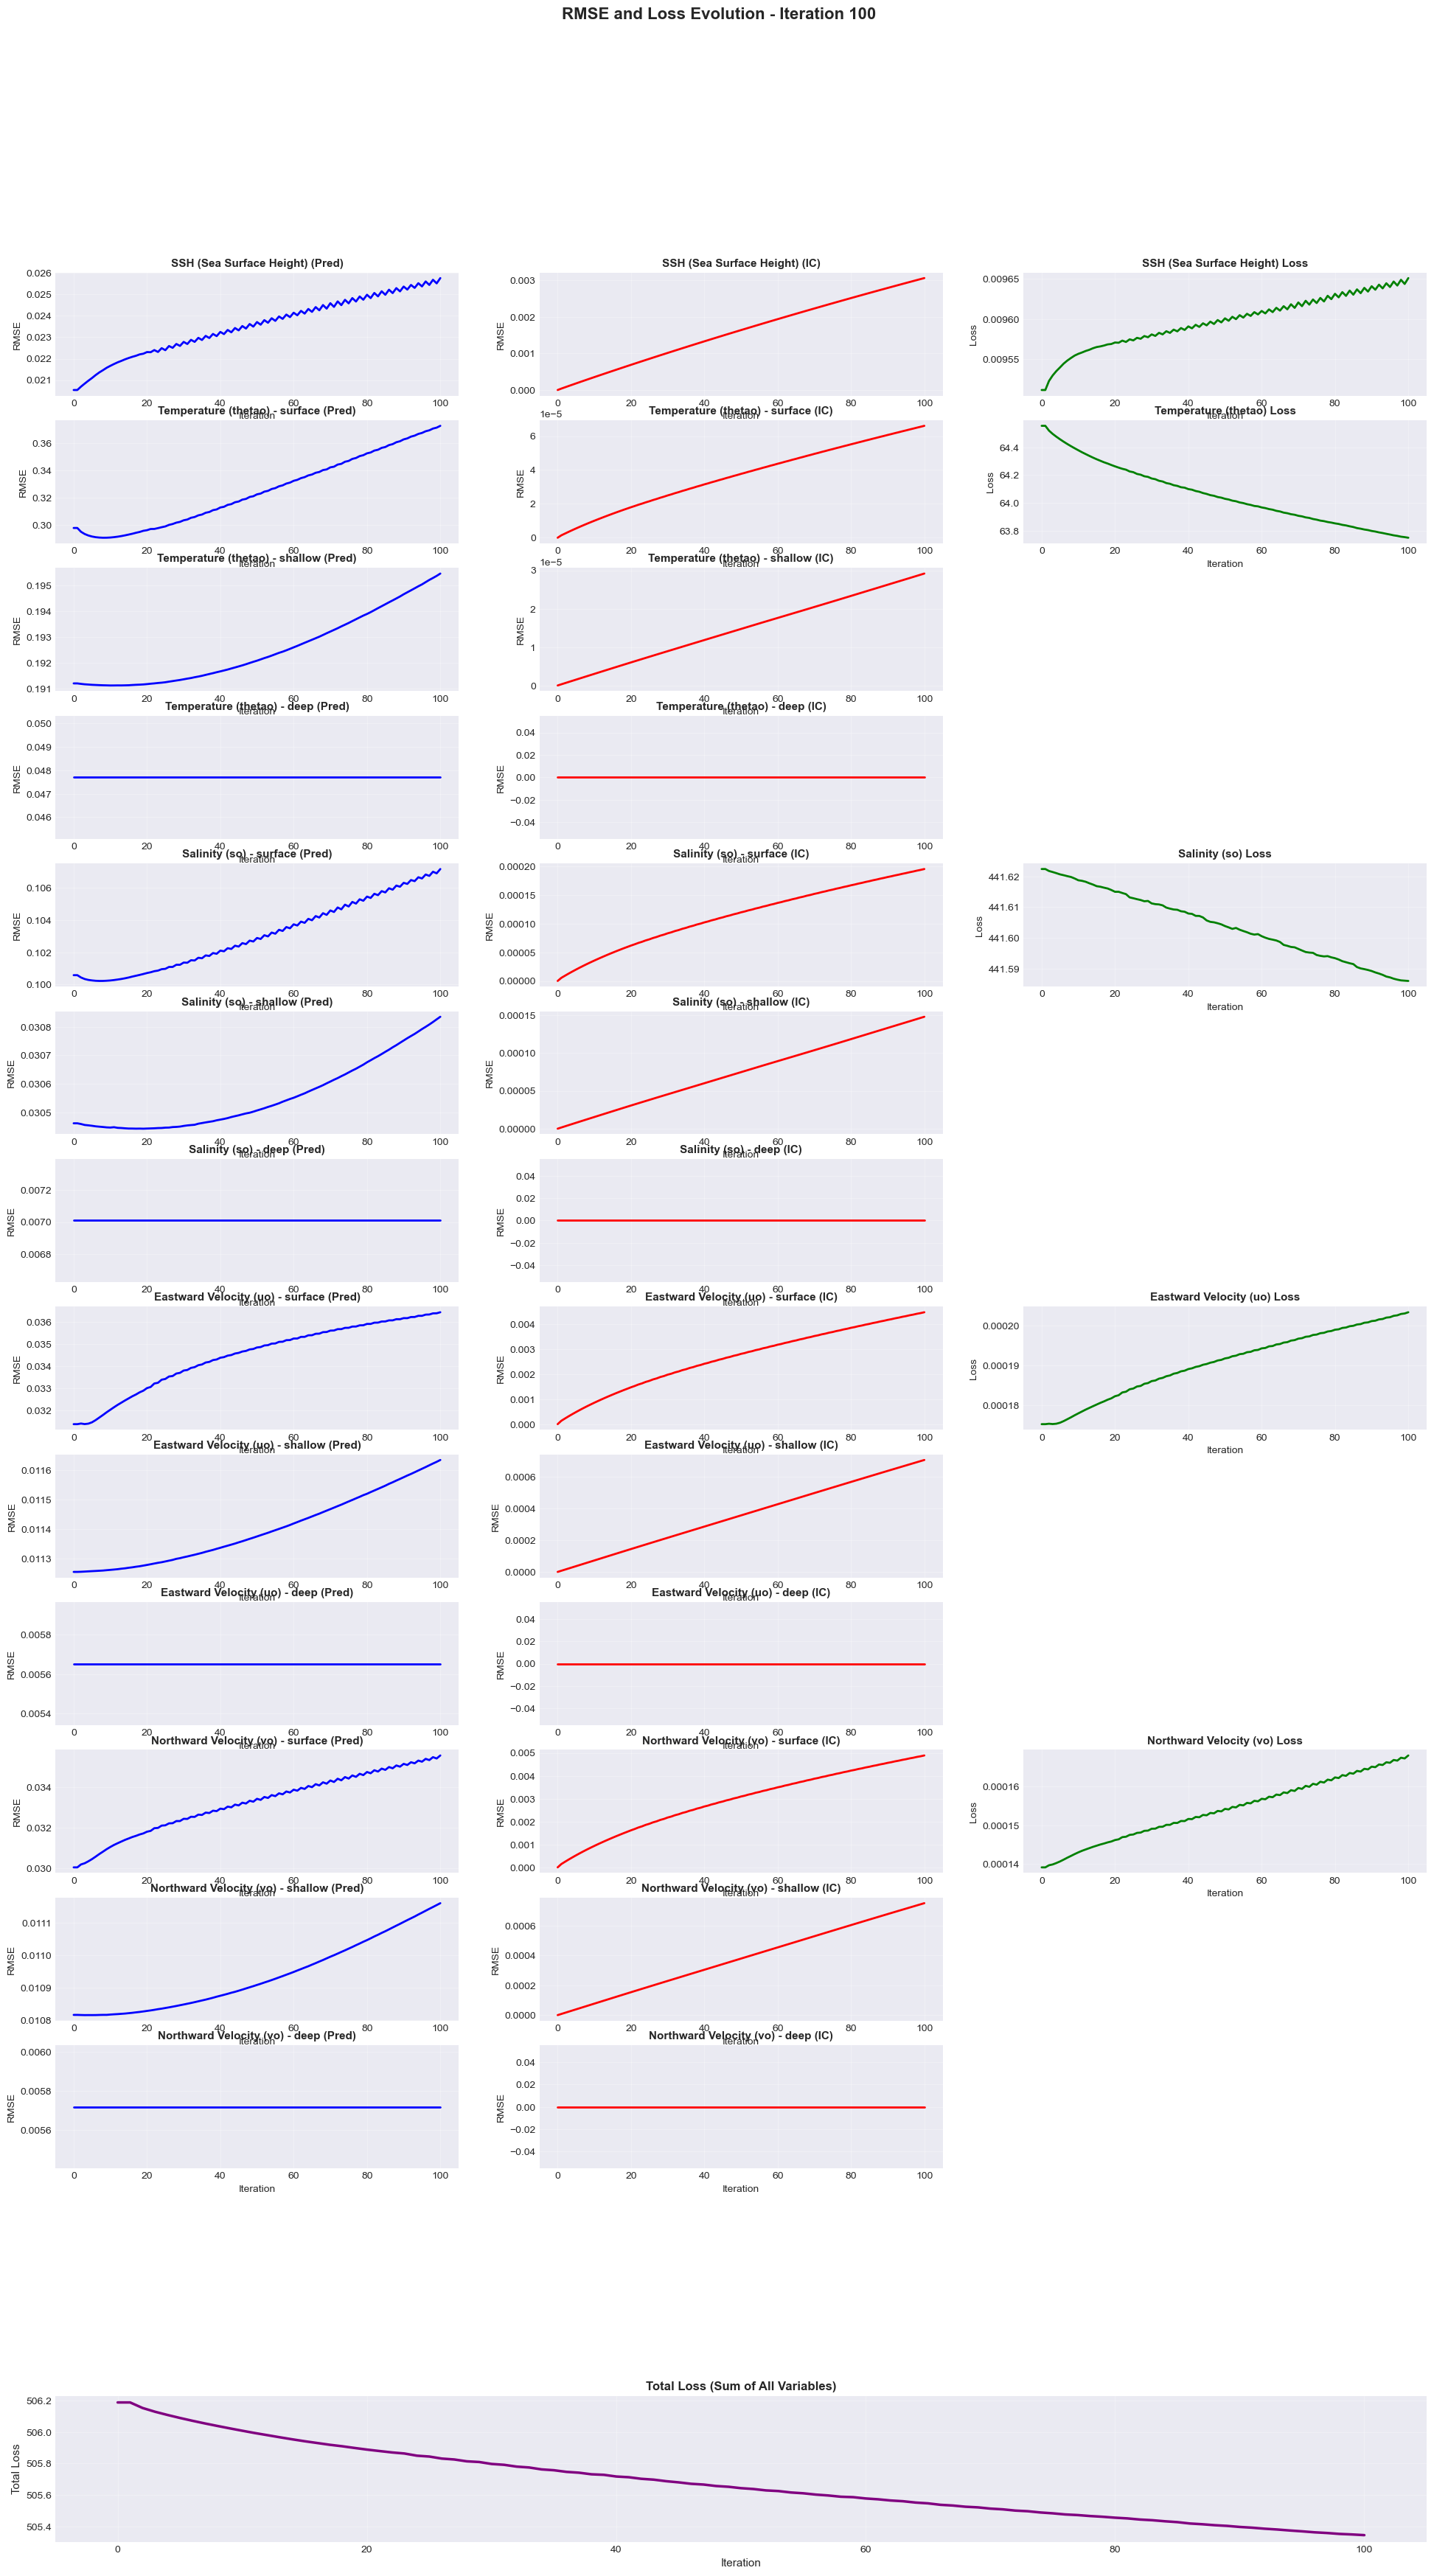

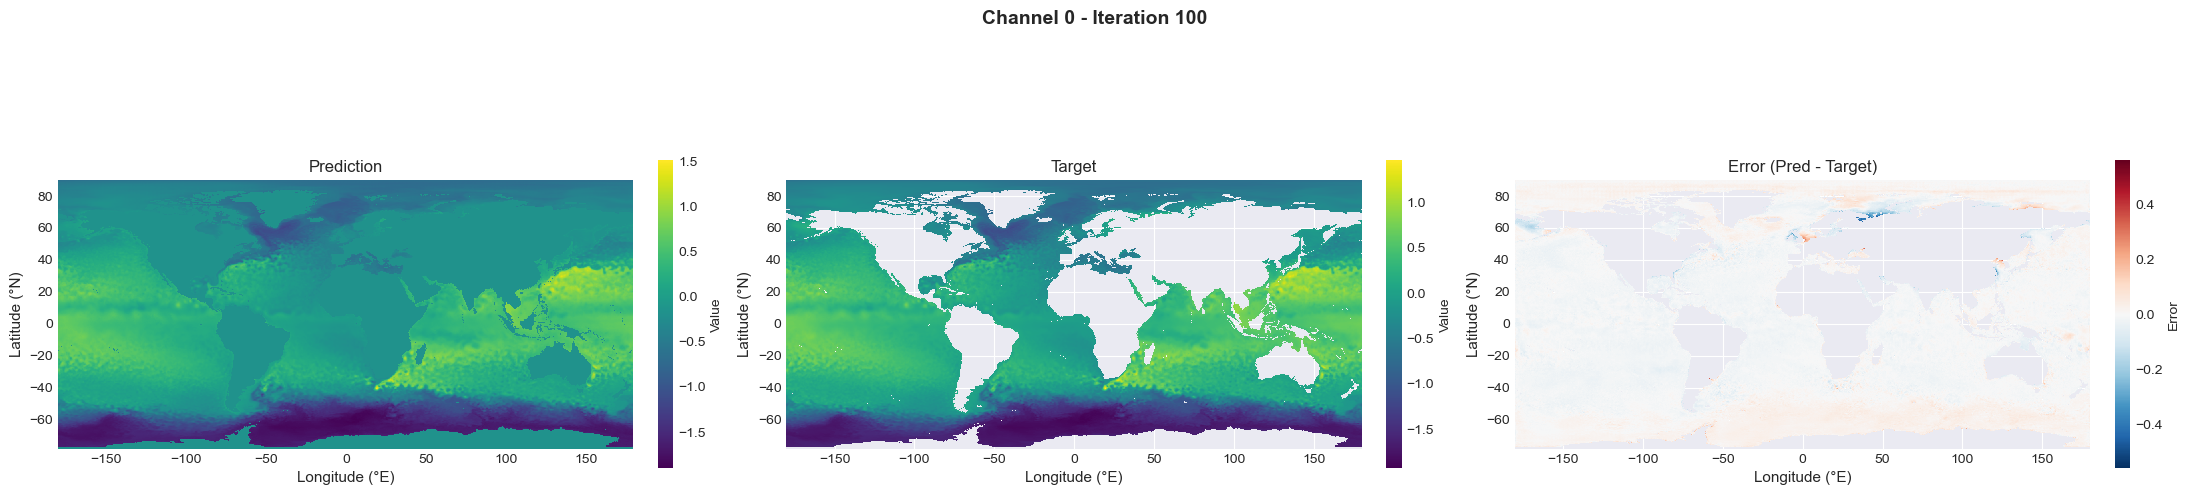


OPTIMIZATION COMPLETE


In [ ]:
for iteration in range(CONFIG['num_iterations']):
    # Zero gradients
    if x0.grad is not None:
        x0.grad.zero_()
    
    # Forward pass
    x0_in_std, y_hat = forward(x0)
    
    # Compute loss
    total_loss, loss_ssh, loss_t, loss_s, loss_u, loss_v = compute_loss(y_hat)
    
    # Backward pass
    grads = torch.autograd.grad(loss_ssh, x0, create_graph=False)
    
    # Apply ocean mask to gradients and update
    with torch.no_grad():
        masked_grad = grads[0] * ocean_mask_all.unsqueeze(0).unsqueeze(0)
        
        # Gradient descent update
        x0 = x0 - CONFIG['learning_rate'] * masked_grad
        
        # Denormalize back to original space
        # x0 = torch.cat([
        #     denormalizer1(x0_in_std_updated[:, :, 0:5, :, :]),
        #     denormalizer2(x0_in_std_updated[:, :, 5:45, :, :]),
        #     denormalizer3(x0_in_std_updated[:, :, 45:85, :, :])
        # ], dim=2)
        x0.requires_grad = True
    
    # Compute metrics
    with torch.no_grad() :
        metrics = compute_rmse_metrics(y_hat, x0, x0_ref)
    
    # Store history
    history.append({
        'loss': total_loss.item(),
        'loss_ssh': loss_ssh.item(),
        'loss_t': loss_t.item(),
        'loss_s': loss_s.item(),
        'loss_u': loss_u.item(),
        'loss_v': loss_v.item(),   
        'pred': metrics['pred'],
        'ic': metrics['ic']
    })
    
    # Update best
    if total_loss.item() < best_loss:
        best_loss = total_loss.item()
        best_y_hat = y_hat.detach().clone()
        best_x0 = x0.detach().clone()
        best_iteration = iteration + 1
    
    # Print and visualize
    if (iteration + 1) % CONFIG['plot_frequency'] == 0 or iteration == 0:
        clear_output(wait=True)
        
        print(f"\n{'='*60}")
        print(f"Iteration {iteration + 1}/{CONFIG['num_iterations']}")
        print(f"{'='*60}")
        print(f"Total Loss: {total_loss.item():.6f}")
        print(f"Best Loss: {best_loss:.6f} (iteration {best_iteration})")
        print(f"\nPrediction RMSE:")
        for var, rmse in metrics['pred'].items():
            if isinstance(rmse, list):
                rmse_str = [f"{r:.6e}" for r in rmse]
                print(f"  {var:10s}: {rmse_str}")
            else:
                print(f"  {var:10s}: {rmse:.6e}")
        print(f"\nInitial Condition RMSE:")
        for var, rmse in metrics['ic'].items():
            if isinstance(rmse, list):
                rmse_str = [f"{r:.6e}" for r in rmse]
                print(f"  {var:10s}: {rmse_str}")
            else:
                print(f"  {var:10s}: {rmse:.6e}")
        
        # Plot RMSE evolution
        fig_rmse = plot_rmse_evolution(history, iteration + 1)
        # plt.savefig(f"{CONFIG['output_dir']}/rmse_evolution_iter{iteration+1:04d}.png", 
        #            dpi=150, bbox_inches='tight')
        plt.show()
        
        # Plot predictions
        fig_pred = plot_predictions(y_hat, target_tensor, coords, iteration + 1, channel_idx=0)
        # plt.savefig(f"{CONFIG['output_dir']}/predictions_iter{iteration+1:04d}.png", 
        #            dpi=150, bbox_inches='tight')
        plt.show()
    
    # Memory cleanup
    del y_hat, total_loss, loss_ssh, loss_t, loss_s, loss_u, loss_v , grads
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

## 9. Final Results and Analysis

In [ ]:
# Final statistics
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Initial Loss: {history[0]['loss']:.6f}")
print(f"Final Loss: {history[-1]['loss']:.6f}")
print(f"Best Loss: {best_loss:.6f} (iteration {best_iteration})")
print(f"Loss Reduction: {(history[0]['loss'] - history[-1]['loss']) / history[0]['loss'] * 100:.2f}%")

print(f"\nFinal Prediction RMSE:")
for var, rmse in history[-1]['pred'].items():
    initial_rmse = history[0]['pred'][var]
    if isinstance(rmse, list):
        rmse_str = [f"{r:.6e}" for r in rmse]
        init_str = [f"{r:.6e}" for r in initial_rmse]
        reductions = [(initial_rmse[i] - rmse[i]) / initial_rmse[i] * 100 for i in range(len(rmse))]
        red_str = [f"{r:+.2f}%" for r in reductions]
        print(f"  {var:10s}: {rmse_str} (reduction: {red_str})")
    else:
        reduction = (initial_rmse - rmse) / initial_rmse * 100
        print(f"  {var:10s}: {rmse:.6e} (reduction: {reduction:+.2f}%)")

print(f"\nFinal IC RMSE:")
for var, rmse in history[-1]['ic'].items():
    if isinstance(rmse, list):
        rmse_str = [f"{r:.6e}" for r in rmse]
        print(f"  {var:10s}: {rmse_str}")
    else:
        print(f"  {var:10s}: {rmse:.6e}")
print("="*60)

In [ ]:
# Plot final RMSE evolution
fig = plot_rmse_evolution(history, len(history)-1)
plt.savefig(f"{CONFIG['output_dir']}/rmse_evolution_final.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Plot best predictions for multiple channels
channels_to_plot = [0, 1, 2, 3, 4]  # SSH, thetao, so, uo, vo (surface)
channel_names = ['SSH', 'thetao (surface)', 'so (surface)', 'uo (surface)', 'vo (surface)']

for ch, name in zip(channels_to_plot, channel_names):
    print(f"\nPlotting channel {ch}: {name}")
    fig = plot_predictions(best_y_hat, target_tensor, coords, best_iteration, channel_idx=ch)
    plt.savefig(f"{CONFIG['output_dir']}/best_prediction_ch{ch}_{name.replace(' ', '_')}.png", 
               dpi=150, bbox_inches='tight')
    plt.show()

## 10. Save Results

In [ ]:
# Save history as DataFrame and JSON
import json

# Save history
history_df = pd.DataFrame([
    {
        'iteration': i,
        'loss': h['loss'],
        **{f'pred_{k}': v for k, v in h['pred'].items()},
        **{f'ic_{k}': v for k, v in h['ic'].items()}
    }
    for i, h in enumerate(history)
])

history_df.to_csv(f"{CONFIG['output_dir']}/optimization_history.csv", index=False)
print(f"✓ Saved optimization history to {CONFIG['output_dir']}/optimization_history.csv")

# Display first few rows
display(history_df.head(10))

In [ ]:
# Save configuration and results
results = {
    'config': CONFIG,
    'initial_loss': history[0]['loss'],
    'final_loss': history[-1]['loss'],
    'best_loss': best_loss,
    'best_iteration': best_iteration,
    'initial_metrics': history[0],
    'final_metrics': history[-1],
}

with open(f"{CONFIG['output_dir']}/results.json", 'w') as f:
    json.dump(results, f, indent=2, default=str)
print(f"✓ Saved results to {CONFIG['output_dir']}/results.json")

In [ ]:
# Save optimized initial conditions
with torch.no_grad():
    opt_x0_np = best_x0.cpu().numpy().squeeze(0)  # [T, 85, H, W]

ds_opt = xr.Dataset({
    'data': (['time', 'ch', 'lat', 'lon'], opt_x0_np)
}, coords={
    'time': coords['time'],
    'ch': np.arange(85),
    'lat': coords['lat'],
    'lon': coords['lon']
})

ds_opt.attrs['description'] = 'Optimized initial conditions from gradient descent'
ds_opt.attrs['creation_date'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ds_opt.attrs['best_loss'] = float(best_loss)
ds_opt.attrs['best_iteration'] = best_iteration
ds_opt.attrs['learning_rate'] = CONFIG['learning_rate']
ds_opt.attrs['num_iterations'] = CONFIG['num_iterations']

encoding = {'data': {'zlib': True, 'complevel': 4}}
ds_opt.to_netcdf(f"{CONFIG['output_dir']}/optimized_initial_conditions.nc", encoding=encoding)
print(f"✓ Saved optimized initial conditions to {CONFIG['output_dir']}/optimized_initial_conditions.nc")

In [ ]:
# Save best predictions
with torch.no_grad():
    best_pred_np = best_y_hat.cpu().numpy()  # [1, 85, H, W]

ds_pred = xr.Dataset({
    'data': (['time', 'ch', 'lat', 'lon'], best_pred_np)
}, coords={
    'time': [coords['target_time']],
    'ch': np.arange(85),
    'lat': coords['lat'],
    'lon': coords['lon']
})

ds_pred.attrs['description'] = 'Best forecast predictions from optimized initial conditions'
ds_pred.attrs['creation_date'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ds_pred.attrs['best_loss'] = float(best_loss)
ds_pred.attrs['best_iteration'] = best_iteration

encoding = {'data': {'zlib': True, 'complevel': 4}}
ds_pred.to_netcdf(f"{CONFIG['output_dir']}/best_predictions.nc", encoding=encoding)
print(f"✓ Saved best predictions to {CONFIG['output_dir']}/best_predictions.nc")

## 11. Optional: Inspect Specific Iterations

You can manually inspect predictions at any iteration stored in the history.

In [ ]:
# Example: Plot RMSE for a specific variable over time
variable = 'SSH'  # Change to: 'thetao', 'so', 'uo', or 'vo'

iterations = list(range(len(history)))
pred_rmse = [h['pred'][variable] for h in history]
ic_rmse = [h['ic'][variable] for h in history]

plt.figure(figsize=(12, 6))
plt.plot(iterations, pred_rmse, 'b-', linewidth=2, label=f'{variable} Prediction RMSE')
plt.plot(iterations, ic_rmse, 'r--', linewidth=2, label=f'{variable} IC RMSE')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title(f'{variable} RMSE Evolution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

All results have been saved to: `{CONFIG['output_dir']}`

### Saved files:
- `optimization_history.csv` - Complete history of losses and RMSE values
- `results.json` - Configuration and summary statistics
- `optimized_initial_conditions.nc` - Best optimized initial conditions
- `best_predictions.nc` - Best forecast predictions
- Multiple PNG visualization files

You can now reload these files for further analysis or use the optimized initial conditions for new forecasts.